Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import re
from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *
from statsforecast import StatsForecast
from statsforecast.models import Naive, HistoricAverage, WindowAverage, SeasonalNaive
from statsforecast.models import AutoARIMA

import warnings
warnings.filterwarnings("ignore")


/Users/devanshujoshi/Documents/Devanshu/USA/Boston University/DS701/ds-muckrock-liberation/fa25-team-a/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Import all the formatted .csv files. (These .csv files have been formatted and cleaned manually from the PDF files provided by the client using tools such as Adobe Express and OCR tools provided by Muckrock)

The database structure is given below :-
- data
    - Financial Statements
        - Financial Statements Format-1.csv
        - Financial Statements Format-2 Europe.csv
        - Financial Statements Format-2 Korea.csv
        - Financial Statements Format-2 Japan.csv
        - Financial Statements Format-3 Europe.csv
        - Financial Statements Format-3 Korea.csv
        - Financial Statements Format-3 Japan.csv
        - Financial Statements Format-4.csv
    - Navy Revenue
        - Navy Revenue Report FY16-FY24-1 Format 1.csv
        - Navy Revenue Report FY20-FY24-1 Format 2.csv
    - Marine Revenue
        - Marine Revenue FY20-FY24 Format 1.csv
        - Marine Revenue FY20-FY24 Format 2.csv
    - District Revenue
        - District Revenue Format 2_2.csv
        - District Revenue Format 2_3.csv
        - District Revenue Format 3.csv
    - Asset Reports
        - Asset Report FY20-FY24 Format 1.csv
        - Asset Report FY20-FY24 Format 2.csv
        - Asset Report FY20-FY24 Format 4.csv
    - bases.json


In [2]:
# State file paths
# Financial Statements
financial_statements_1_path = 'data/Financial Statements/Financial Statements Format-1.csv'
financial_statements_2_europe_path = 'data/Financial Statements/Financial Statements Format-2 Europe.csv'
financial_statements_2_korea_path = 'data/Financial Statements/Financial Statements Format-2 Korea.csv'
financial_statements_2_japan_path = 'data/Financial Statements/Financial Statements Format-2 Japan.csv'
financial_statements_3_europe_path = 'data/Financial Statements/Financial Statements Format-3 Europe.csv'
financial_statements_3_korea_path = 'data/Financial Statements/Financial Statements Format-3 Korea.csv'
financial_statements_3_japan_path = 'data/Financial Statements/Financial Statements Format-3 Japan.csv'
financial_statements_4_path = 'data/Financial Statements/Financial Statements Format-4.csv'

# Navy Revenue
navy_revenue_1_path = 'data/Navy Revenue/Navy Revenue Report FY16-FY24-1 Format 1.csv'
navy_revenue_2_path = 'data/Navy Revenue/Navy Revenue Report FY20-FY24-1 Format 2.csv'

# Marine Revenue
marine_revenue_1_path = 'data/Marine Revenue/Marine Revenue FY20-FY24 Format 1.csv'
marine_revenue_2_path = 'data/Marine Revenue/Marine Revenue FY20-FY24 Format 2.csv'

# Base Location
bases_file_path = 'data/bases.json'

In [3]:
# Import and read csv files
# Financial Statements
fs1 = pd.read_csv(financial_statements_1_path)
fs2e = pd.read_csv(financial_statements_2_europe_path)
fs2k = pd.read_csv(financial_statements_2_korea_path)
fs2j = pd.read_csv(financial_statements_2_japan_path)
fs3e = pd.read_csv(financial_statements_3_europe_path)
fs3k = pd.read_csv(financial_statements_3_korea_path)
fs3j = pd.read_csv(financial_statements_3_japan_path)
fs4 = pd.read_csv(financial_statements_4_path)

# Navy Revenue
nr1 = pd.read_csv(navy_revenue_1_path)
nr2 = pd.read_csv(navy_revenue_2_path)

# Marine Revenue
mr1 = pd.read_csv(marine_revenue_1_path)
mr2 = pd.read_csv(marine_revenue_2_path)

# Bases Locations
bases = pd.read_json(bases_file_path)

### Analyze and Preprocess

Analyze the database structure for "Financial Statements Format-1.csv" from the variable 'fs1'

In [4]:
# List of desired unique values
desired_values = [
    'Cash--Operating', 'Cash--Restricted', 'Accounts Receivable',
    'Prepaid Expenses', 'Fixed Assets', 'Less Accum Depreciation',
    'TOTAL ASSETS',
    'Accounts Payable', 'Distributions Payable', 'Accrued Liabilities',
    'Accrued Salaries', 'Accrued Leave Payable', 'Total Liabilities',
    'EQUITY', 'TOTAL LIABILITIES & EQUITY'
]

# Function to normalize each entry
def normalize_value(val):
    if pd.isna(val):
        return val
    val = val.strip()  # Remove leading/trailing spaces
    val = ' '.join(val.split())  # Replace multiple spaces with single
    val = val.replace('.', '')  # Remove any dots
    # Match closest desired value
    for d in desired_values:
        if val.lower() == d.lower():
            return d
    return val  # If no match, keep as is

# Apply normalization to the 'Details' column
fs1['Details'] = fs1['Details'].apply(normalize_value)

# Check unique values now
print(fs1['Details'].unique())


['Cash--Operating' 'Cash--Restricted' 'Accounts Receivable'
 'Prepaid Expenses' 'Fixed Assets' 'Less Accum Depreciation'
 'TOTAL ASSETS' 'Accounts Payable' 'Distributions Payable'
 'Accrued Liabilities' 'Accrued Salaries' 'Accrued Leave Payable'
 'Total Liabilities' 'EQUITY' 'TOTAL LIABILITIES & EQUITY' 'Cash'
 'Less Accum Pepreciation' 'LIABILITIES' 'Total Liabilities EQUITY']


From the data we can clean and categorize it on the basis of the following :-
- Base name
- Currency Value (if there are still any issues in the currency formatting)
- Military Branch
- Region in which the Branch is located:-
    - Europe
    - Korea
    - Japan
    - Singapore
    - Other (If any)
- Monthly Revenue

In [5]:
def formate_value(val):
    if pd.isna(val):
        return val
    val = val.strip()
    val = val.replace('"', '')
    val = val.replace(',', '')
    val = val.replace("-", '')            
    val = val.replace(" ", '')
    val = val.replace("·", '')
    val = float(val)
    return val

def to_string(val):
    if pd.isna(val):
        return val
    val = str(val)
    return val

# Convert Numeric Values
fs4["March Europe"] = fs4["March Europe"].apply(formate_value)
fs4["March Korea"] = fs4["March Korea"].apply(formate_value)
fs4["March Japan"] = fs4["March Japan"].apply(formate_value)
fs4["YTD\nEurope"] = fs4["YTD\nEurope"].apply(formate_value)
fs4["YTD\nKorea"] = fs4["YTD\nKorea"].apply(formate_value)
fs4["YTD\nJapan"] = fs4["YTD\nJapan"].apply(formate_value)

# Convert to date and time
fs4["Year"] = fs4["Year"].apply(to_string)
fs4["MonthYearString"] = fs4["Month"] + ' ' + fs4["Year"]
fs4['Last_Day_Date'] = pd.to_datetime(fs4['MonthYearString'], format="%B %Y") + pd.tseries.offsets.MonthEnd(0)


In [6]:
def clean_base_name(name):
    """Clean and standardize base names by removing extra spaces and standardizing formatting"""
    if pd.isna(name):
        return name
    
    # Remove extra spaces (multiple spaces, tabs, etc.)
    name = re.sub(r'\s+', ' ', str(name).strip())
    
    # Standardize common base name variations
    # name = re.sub(r'Camp\s+', 'Camp ', name)
    # name = re.sub(r'AFRC\s+', 'AFRC ', name)
    # name = re.sub(r'Navy\s*$', 'Navy', name)
    # name = re.sub(r'Marines\s*$', 'Marines', name)
    
    # Specific known variations - ensure they match our TOP_10_BASES
    name = name.replace('Casey &   Hovey', 'Casey & Hovey')
    name = name.replace('Casey & Hovey', 'Casey & Hovey')
    name = name.replace('Camp     Humphreys', 'Camp Humphreys')
    name = name.replace('AFRC   Dragon   Hill   Lodge', 'AFRC Dragon Hill Lodge')
    name = name.replace('AFRC  Dragon  Hill  Lodge', 'AFRC Dragon Hill Lodge')
    name = name.replace('Sanna Navy', 'Sanno Navy')  # Fix typo
    name = name.replace('Wiesb3den', 'Wiesbaden')  # Fix typo
    name = name.replace('Ansb3ch', 'Ansbach')  # Fix typo
    
    # # Ensure base names match our predefined list
    # for base in TOP_10_BASES:
    #     if base.lower() in name.lower():
    #         return base
    
    return name.strip()

def clean_currency_value(value):
    """Clean and convert currency string to float"""
    if pd.isna(value) or value == '' or value == 0.00:
        return 0.0
    
    # Handle negative values and various formats
    if isinstance(value, str):
        # Remove commas and spaces
        value = value.replace(',', '').replace(' ', '')
        # Handle negative values with parentheses or minus sign
        if '(' in value and ')' in value:
            value = '-' + value.replace('(', '').replace(')', '')
        # Handle trailing minus sign
        if value.endswith('-'):
            value = '-' + value[:-1]
        # Remove any non-numeric characters except decimal point and minus
        value = re.sub(r'[^\d.-]', '', value)
        
        if value == '' or value == '-':
            return 0.0
    
    try:
        return float(value)
    except (ValueError, TypeError):
        return 0.0

def categorize_branch(location):
    """Categorize locations by military branch"""
    location_lower = str(location).lower()
    
    if 'navy' in location_lower:
        return 'Navy'
    elif 'marines' in location_lower:
        return 'Marines'
    elif any(word in location_lower for word in ['army', 'ansbach', 'baumholder', 'grafenwoehr', 'hohenfels', 'wiesbaden']):
        return 'Army'
    elif 'air' in location_lower or 'afrc' in location_lower:
        return 'Air Force'
    else:
        return 'Total'

def categorize_region(location):
    """Categorize locations by geographic region"""
    location_lower = str(location).lower()
    
    if any(word in location_lower for word in ['germany', 'europe', 'kaiserslautern', 'grafenwoehr', 
                                            'wiesbaden', 'vicenza', 'livorno', 'stuttgart', 
                                            'baumholder', 'ansbach', 'schinnen', 'hohenfels',
                                            'naples', 'sigonella', 'rota', 'souda', 'brunssum']):
        return 'Europe'
    elif any(word in location_lower for word in ['korea', 'seoul', 'casey', 'hovey', 'uijongbu', 
                                                'humphreys', 'daegu', 'chinhae', 'mujuk']):
        return 'Korea'
    elif any(word in location_lower for word in ['japan', 'zama', 'fuji', 'sanno', 'atsugi', 
                                                'okinawa', 'iwakuni', 'sasebo', 'yokosuka']):
        return 'Japan'
    elif 'singapore' in location_lower:
        return 'Singapore'
    else:
        return 'Other'

def load_and_clean_data(file_path):
    """Load and clean the financial data"""
    df = pd.read_csv(file_path)
    
    # Clean column names
    df.columns = [col.replace('\n', ' ').strip() for col in df.columns]
    
    # Clean base names first
    df['Locations'] = df['Locations'].apply(clean_base_name)
    
    # Clean monetary columns
    monetary_columns = ['March Europe', 'March Korea', 'March Japan', 
                        'YTD Europe', 'YTD Korea', 'YTD Japan']
    
    for col in monetary_columns:
        df[col] = df[col].apply(clean_currency_value)
    
    # Filter out total rows for base-level analysis
    # df = df[~df['Locations'].str.contains('Total', na=False)]
    df = df[~df['Locations'].str.contains('Europe', na=False)]  # Remove summary rows
    
    # Filter to only include our predefined top 10 bases
    # df = df[df['Locations'].isin(TOP_10_BASES)]
    
    # Add branch and region categories
    df['Branch'] = df['Locations'].apply(categorize_branch)
    df['Region'] = df['Locations'].apply(categorize_region)
    
    # Create a proper datetime column
    df['Date'] = pd.to_datetime(df['Month'] + ' ' + df['Year'].astype(str))
    
    return df

def create_monthly_revenue_column(df):
    """Create a monthly revenue column by summing across regions"""
    df['Monthly_Revenue'] = df[['March Europe', 'March Korea', 'March Japan']].sum(axis=1)
    df['YTD_Revenue'] = df[['YTD Europe', 'YTD Korea', 'YTD Japan']].sum(axis=1)
    return df

In [7]:
# Load and clean data
print("Loading and cleaning data...")
df = load_and_clean_data('data/Financial Statements/Financial Statements Format-4.csv')
df = create_monthly_revenue_column(df)


Loading and cleaning data...


In [8]:
df

,Unnamed: 0,Locations,March Europe,March Korea,March Japan,YTD Europe,YTD Korea,YTD Japan,Month,Year,latitude,longitude,Branch,Region,Date,Monthly_Revenue,YTD_Revenue
0,0,Kaiserslautern,435381.00,0.00,0.00,1769195.35,0.0,0.00,March,2023,NaN,NaN,Total,Europe,2023-03-01,435381.00,1769195.35
1,1,Grafenwoehr,148145.60,0.00,0.00,827100.45,0.0,0.00,March,2023,NaN,NaN,Army,Europe,2023-03-01,148145.60,827100.45
2,2,Wiesbaden,265851.45,0.00,0.00,1376947.40,0.0,0.00,March,2023,NaN,NaN,Army,Europe,2023-03-01,265851.45,1376947.40
3,3,Vicenza,91264.15,0.00,0.00,485232.45,0.0,0.00,March,2023,45.545479,11.535421,Total,Europe,2023-03-01,91264.15,485232.45
4,4,Livorno,9019.10,0.00,0.00,73555.45,0.0,0.00,March,2023,43.548473,10.310567,Total,Europe,2023-03-01,9019.10,73555.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1629,1629,Iwakuni Marines,0.00,0.00,167680.35,0.00,0.0,535915.30,December,2023,NaN,NaN,Marines,Japan,2023-12-01,167680.35,535915.30
1630,1630,Sasebo Navy,0.00,0.00,111517.10,0.00,0.0,651567.15,December,2023,NaN,NaN,Navy,Japan,2023-12-01,111517.10,651567.15
1631,1631,Yokosuka Navy,0.00,0.00,389418.85,0.00,0.0,1273000.40,December,2023,NaN,NaN,Navy,Japan,2023-12-01,389418.85,1273000.40
1632,1632,Singapore Navy,0.00,0.00,1209.70,0.00,0.0,3948.20,December,2023,NaN,NaN,Navy,Singapore,2023-12-01,1209.70,3948.20


Now, we can see that the data has been cleaned and is spread over across 1633 rows and 17 columns. We can now start making forecasts.

In [9]:
future_data = pd.DataFrame()
future_data[['unique_id', 'ds', 'y']] = df[['Locations', 'Date', 'Monthly_Revenue']]

future_data["ds"] = pd.to_datetime(future_data["ds"])
future_data = future_data.sort_values(by='ds', ascending=True)


From the data that we have the below provided attributes are necessary for the Time-Series Analysis:-
- Locations (Since we want to predict revenue for every location)
- Date (Primary factor)
- Monthly_Revenue (The major factor which we want to predict)

utilsforcast and statsforcast require, table attributes as "_unique-id_", "_ds_" and "_y_" for the analysis. Let us map these with our data. We get:-

- unique_id -> Locations (Predict based on the locations)
- ds -> Date
- y (Target variable) -> Monthly_Revenue (Our prediction target variable)

In [10]:
future_data['unique_id'].unique()

array(['Uijongbu', 'Yokosuka Navy', 'Sasebo Navy', 'Iwakuni Marines',
       'Okinawa Navy', 'Okinawa Marines', 'Okinawa', 'Atsugi Navy',
       'Sanno Navy', 'Fuji Marines', 'Camp Zama', 'Camp Mujuk Marines',
       'Chinhae Navy', 'Daegu', 'Camp Humphreys', 'Singapore Navy',
       'Casey & Hovey', 'AFRC Dragon Hill Lodge', 'Souda Bay Navy',
       'Rota Navy', 'Sigonella Navy', 'Naples Navy', 'Hohenfels',
       'AFRC Edelweiss', 'Schinnen', 'Ansbach', 'Baumholder', 'Stuttgart',
       'Livorno', 'Vicenza', 'Wiesbaden', 'Seoul', 'Grafenwoehr',
       'Kaiserslautern', 'AFRC Edelweiss Lodge', 'Total Gaming Revenue',
       'Camp Hunphreys', 'Brunssum'], dtype=object)

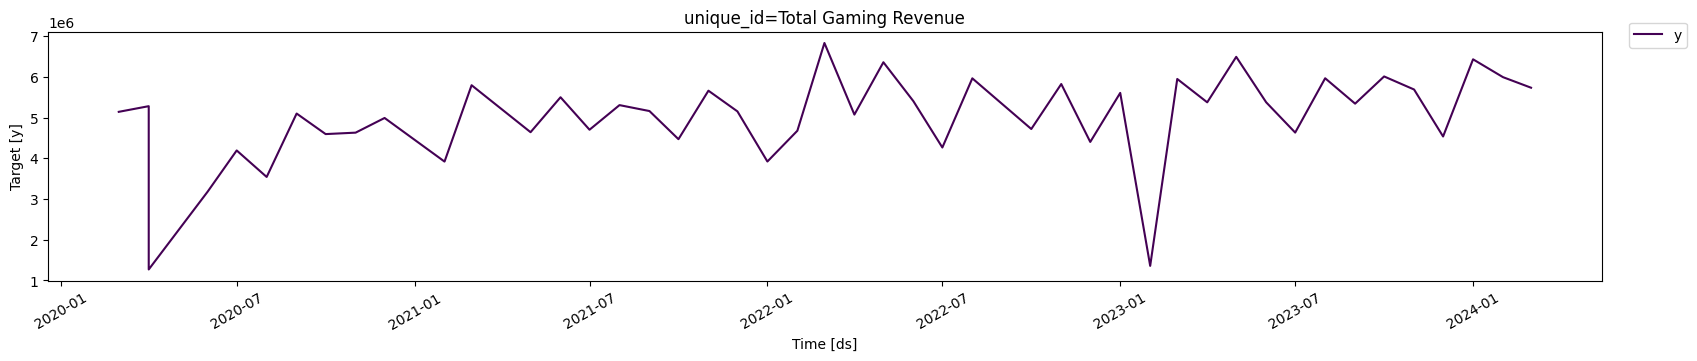

In [11]:
plot_series(df=future_data, ids=["Total Gaming Revenue"], palette="viridis")

From the above graph, we can see a general trend that the Total Gaming Revenue per quarter is having a minor inclination. Which means, the revenue generation is increasing steadily.

Let us train a few Time-Series Predictive models, with parameters:-

- horizon = 12 -> We want to forecast for next 12 months
- season_length = 12 -> 1 season is 1 year for our case (we have 12 months in a year) (Look at the scenario of the same month last year)
- window_size = 3 -> Look at previous 3 months to generate a hypothesis for the upcoming month

In [12]:
horizon = 12

models = [
    Naive(),
    HistoricAverage(),
    WindowAverage(window_size=3),
    SeasonalNaive(season_length=12)
]

sf = StatsForecast(models=models, freq="MS")
sf.fit(df=future_data)
preds = sf.predict(h=horizon)

In [13]:
preds.head()

,unique_id,ds,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,AFRC Dragon Hill Lodge,2024-04-01,485680.9,369784.496596,357532.5,459685.70
1,AFRC Dragon Hill Lodge,2024-05-01,485680.9,369784.496596,357532.5,699038.75
2,AFRC Dragon Hill Lodge,2024-06-01,485680.9,369784.496596,357532.5,298337.00
3,AFRC Dragon Hill Lodge,2024-07-01,485680.9,369784.496596,357532.5,322194.80
4,AFRC Dragon Hill Lodge,2024-08-01,485680.9,369784.496596,357532.5,379928.10


We are not able to get any idea from the above table, let us plot the training and the testing data.

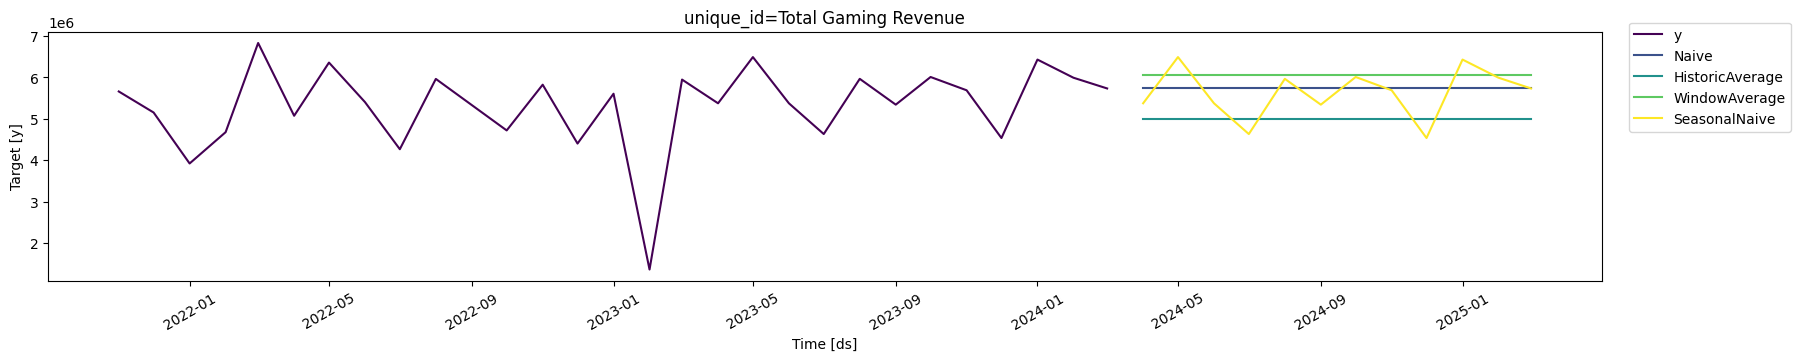

In [14]:
plot_series(
    df=future_data, 
    forecasts_df=preds, 
    ids=["Total Gaming Revenue"], 
    max_insample_length=28, 
    palette="viridis")

It seems much clear that the Naive, Historic Average and Window Average are not able to perform accurate analysis on the provided data but Seasonal Naive has better results.

Let us try to find their error by training and testing data.

In [15]:
test = future_data.groupby("unique_id").tail(1)
train = future_data.drop(test.index).reset_index(drop=True)


In [16]:
sf.fit(df=train)

preds = sf.predict(h=horizon)

eval_df = pd.merge(test, preds, 'left', ['ds', 'unique_id'])

In [17]:
evaluation = evaluate(
    eval_df,
    metrics=[mae],
)
evaluation.head()

,unique_id,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,AFRC Dragon Hill Lodge,mae,485680.90,118415.890435,230042.800000,240820.25
1,AFRC Edelweiss,mae,NaN,NaN,NaN,NaN
2,AFRC Edelweiss Lodge,mae,2768.70,16770.757778,8092.170000,11980.25
3,Ansbach,mae,14578.50,27469.584565,5019.556667,5277.30
4,Atsugi Navy,mae,52078.75,33860.416522,15682.200000,74222.25


In [18]:
evaluation = evaluation.drop(['unique_id'], axis=1).groupby('metric').mean().reset_index()
evaluation

,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,mae,111516.616667,63307.626632,44732.109259,52158.986667


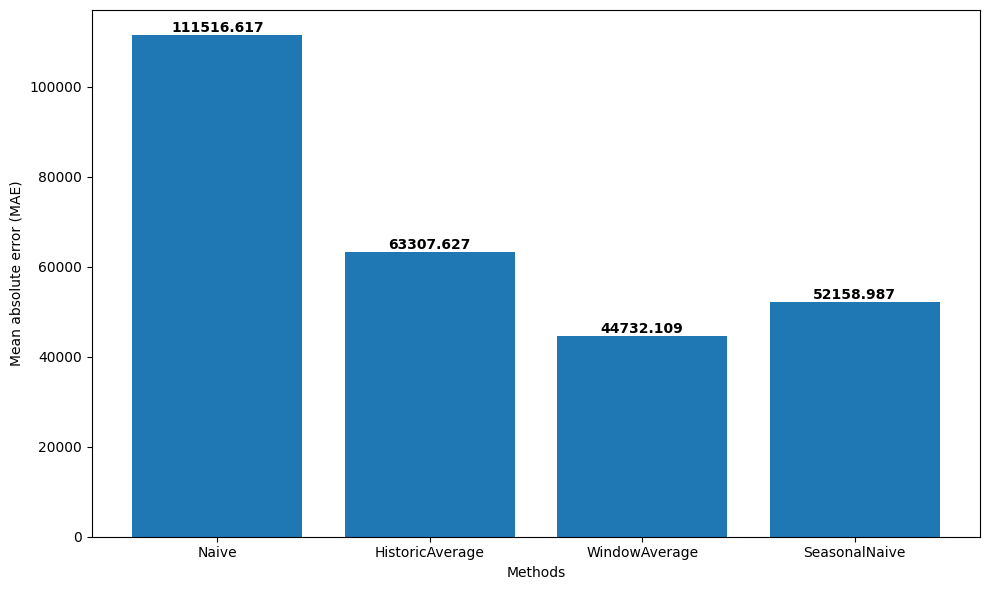

In [19]:
methods = evaluation.columns[1:].tolist()  
values = evaluation.iloc[0, 1:].tolist() 

plt.figure(figsize=(10, 6))
bars = plt.bar(methods, values)

for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.xlabel('Methods')
plt.ylabel('Mean absolute error (MAE)')
plt.tight_layout()

plt.show()

From the above plot, we get an interpretation that Window Average has the best performance with least amount of error but that is incorrect since Window Average gave us a straight line. So, we will be going on with Seasonal Naive.

Also, there are a few models left to explore which are ARIMA and SARIMA. Let us try to compare their accuracies with Seasonal Naive.

In [20]:
unique_ids = ["Total Gaming Revenue"]

small_train = train[train["unique_id"].isin(unique_ids)]
small_test = test[test["unique_id"].isin(unique_ids)]

models = [
    AutoARIMA(seasonal=False, alias="ARIMA"),
    AutoARIMA(season_length=12, alias="SARIMA")
]

sf = StatsForecast(models=models, freq="MS")
sf.fit(df=small_train)
arima_preds = sf.predict(h=horizon)

arima_eval_df = pd.merge(arima_preds, eval_df, 'inner', ['ds', 'unique_id'])
arima_eval = evaluate(
    arima_eval_df,
    metrics=[mae],
)
arima_eval

,unique_id,metric,ARIMA,SARIMA,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,Total Gaming Revenue,mae,249565.512192,249565.512192,259234.36,746958.202444,80496.103333,214415.81


In [21]:
arima_eval = arima_eval.drop(['unique_id'], axis=1).groupby('metric').mean().reset_index()
arima_eval

,metric,ARIMA,SARIMA,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,mae,249565.512192,249565.512192,259234.36,746958.202444,80496.103333,214415.81


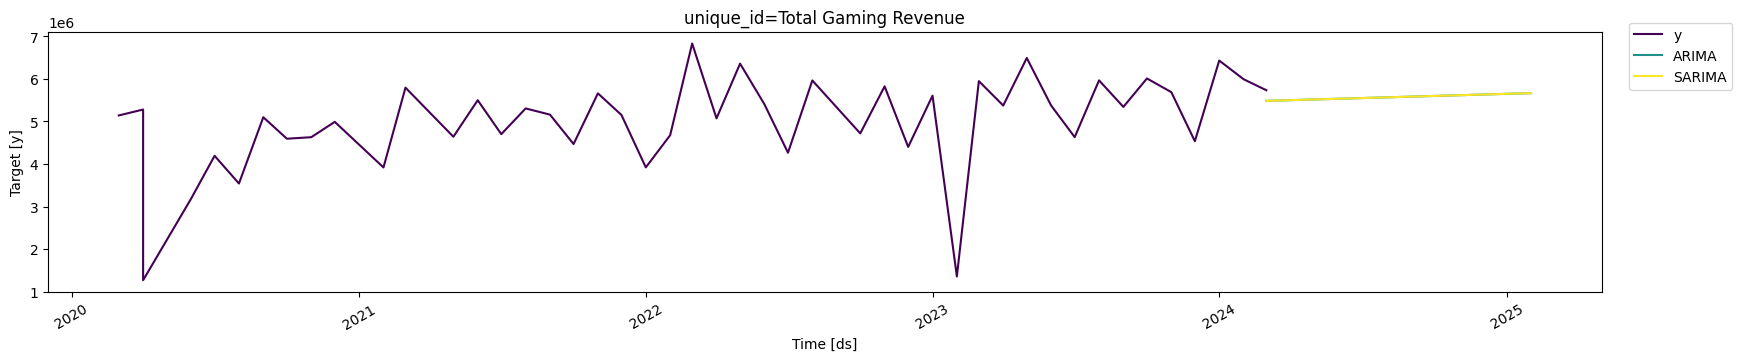

In [22]:
plot_series(
    df=future_data, 
    forecasts_df=arima_preds, 
    ids=["Total Gaming Revenue"], 
    palette="viridis")

Here, we are seeing a similar pattern that ARIMA and SARIMA are giving us a straight line and that is incorrect for the time-series forecast, hence we will again be moving on with Seasonal Naive.

In [23]:
small_df = future_data[future_data["unique_id"].isin(unique_ids)]

models = [
    SeasonalNaive(season_length=12),
    AutoARIMA(seasonal=False, alias="ARIMA"),
    AutoARIMA(season_length=12, alias="SARIMA")
]

sf = StatsForecast(models=models, freq="MS")
cv_df = sf.cross_validation(
    h=horizon, # 7 days
    df=small_df,
    n_windows=3,
    step_size=horizon,
    refit=True
)

cv_df.head()

,unique_id,ds,cutoff,y,SeasonalNaive,ARIMA,SARIMA
0,Total Gaming Revenue,2021-02-01,2020-12-01,3918661.65,5141524.52,4191979.137,4191979.137
1,Total Gaming Revenue,2021-03-01,2020-12-01,5795515.17,5280715.88,4191979.137,4191979.137
2,Total Gaming Revenue,2021-05-01,2020-12-01,4640959.30,1267718.90,4191979.137,4191979.137
3,Total Gaming Revenue,2021-06-01,2020-12-01,5499744.90,3181867.00,4191979.137,4191979.137
4,Total Gaming Revenue,2021-07-01,2020-12-01,4701736.50,4192283.00,4191979.137,4191979.137


Let us predict and see if we have any improvements and this time we will be overlapping it with our original data

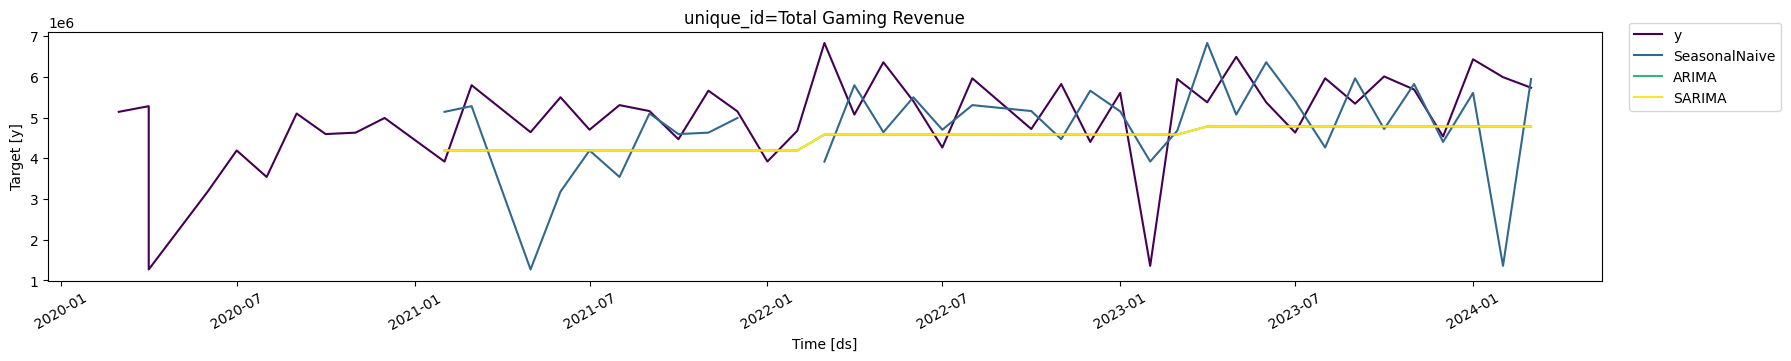

In [24]:
plot_series(
    df=small_df, 
    forecasts_df=cv_df.drop(["y", "cutoff"], axis=1), 
    ids=["Total Gaming Revenue"], 
    max_insample_length=140, 
    palette="viridis"
    )

Again, ARIMA and SARIMA overlapped each other but Seasonal Naive had pretty good performance in comparison to these models.

Now that we have got our base model, let us train Seasonal Naive to preform future predictions.

In [25]:
models = [SeasonalNaive(season_length=12)]
sf = StatsForecast(models=models, freq="MS")
sf.fit(df=train)

# Create future dates for 12-month forecast
unique_ids = train['unique_id'].unique()
n_series = len(unique_ids)

future_data = []
for uid in unique_ids:
    # Get last date for this series
    last_date = train[train['unique_id'] == uid]['ds'].max()
    
    # Generate 12 future months
    future_dates = pd.date_range(
        start=last_date + pd.DateOffset(months=1),
        periods=horizon,  # horizon = 12
        freq='MS'
    )
    
    for date in future_dates:
        future_data.append({
            'unique_id': uid,
            'ds': date
        })

X_df_future = pd.DataFrame(future_data)
print(f"Created future dates dataframe with shape: {X_df_future.shape}")  # Should be (420, 2)

# Predict with the future dates
prob_preds = sf.predict(h=horizon, X_df=X_df_future, level=[80])
print(f"Forecasts shape: {prob_preds.shape}")  # Should be (420, ...)
prob_preds

Created future dates dataframe with shape: (432, 2)
Forecasts shape: (432, 5)


,unique_id,ds,SeasonalNaive,SeasonalNaive-lo-80,SeasonalNaive-hi-80
0,AFRC Dragon Hill Lodge,2024-03-01,244860.65,-54015.725587,543737.025587
1,AFRC Dragon Hill Lodge,2024-04-01,459685.70,160809.324413,758562.075587
2,AFRC Dragon Hill Lodge,2024-05-01,699038.75,400162.374413,997915.125587
3,AFRC Dragon Hill Lodge,2024-06-01,298337.00,-539.375587,597213.375587
4,AFRC Dragon Hill Lodge,2024-07-01,322194.80,23318.424413,621071.175587
...,...,...,...,...,...
427,Yokosuka Navy,2024-10-01,506114.55,285095.523766,727133.576234
428,Yokosuka Navy,2024-11-01,377467.00,156447.973766,598486.026234
429,Yokosuka Navy,2024-12-01,389418.85,168399.823766,610437.876234
430,Yokosuka Navy,2025-01-01,440682.60,219663.573766,661701.626234


In the above table, _SeasonalNaive-lo-80_ and _SeasonalNaive-lo-80_ are the confidence ranges in the lowest and highest respectively for the prediction that has been made by our model. And the column SeasonalNaive has the predictions for the future values.

In [26]:
test_df = test.merge(prob_preds, on=["unique_id", "ds"], how="left")

Let us plot our predictions for a few popular bases and also the trend for Total Gaming Revenue

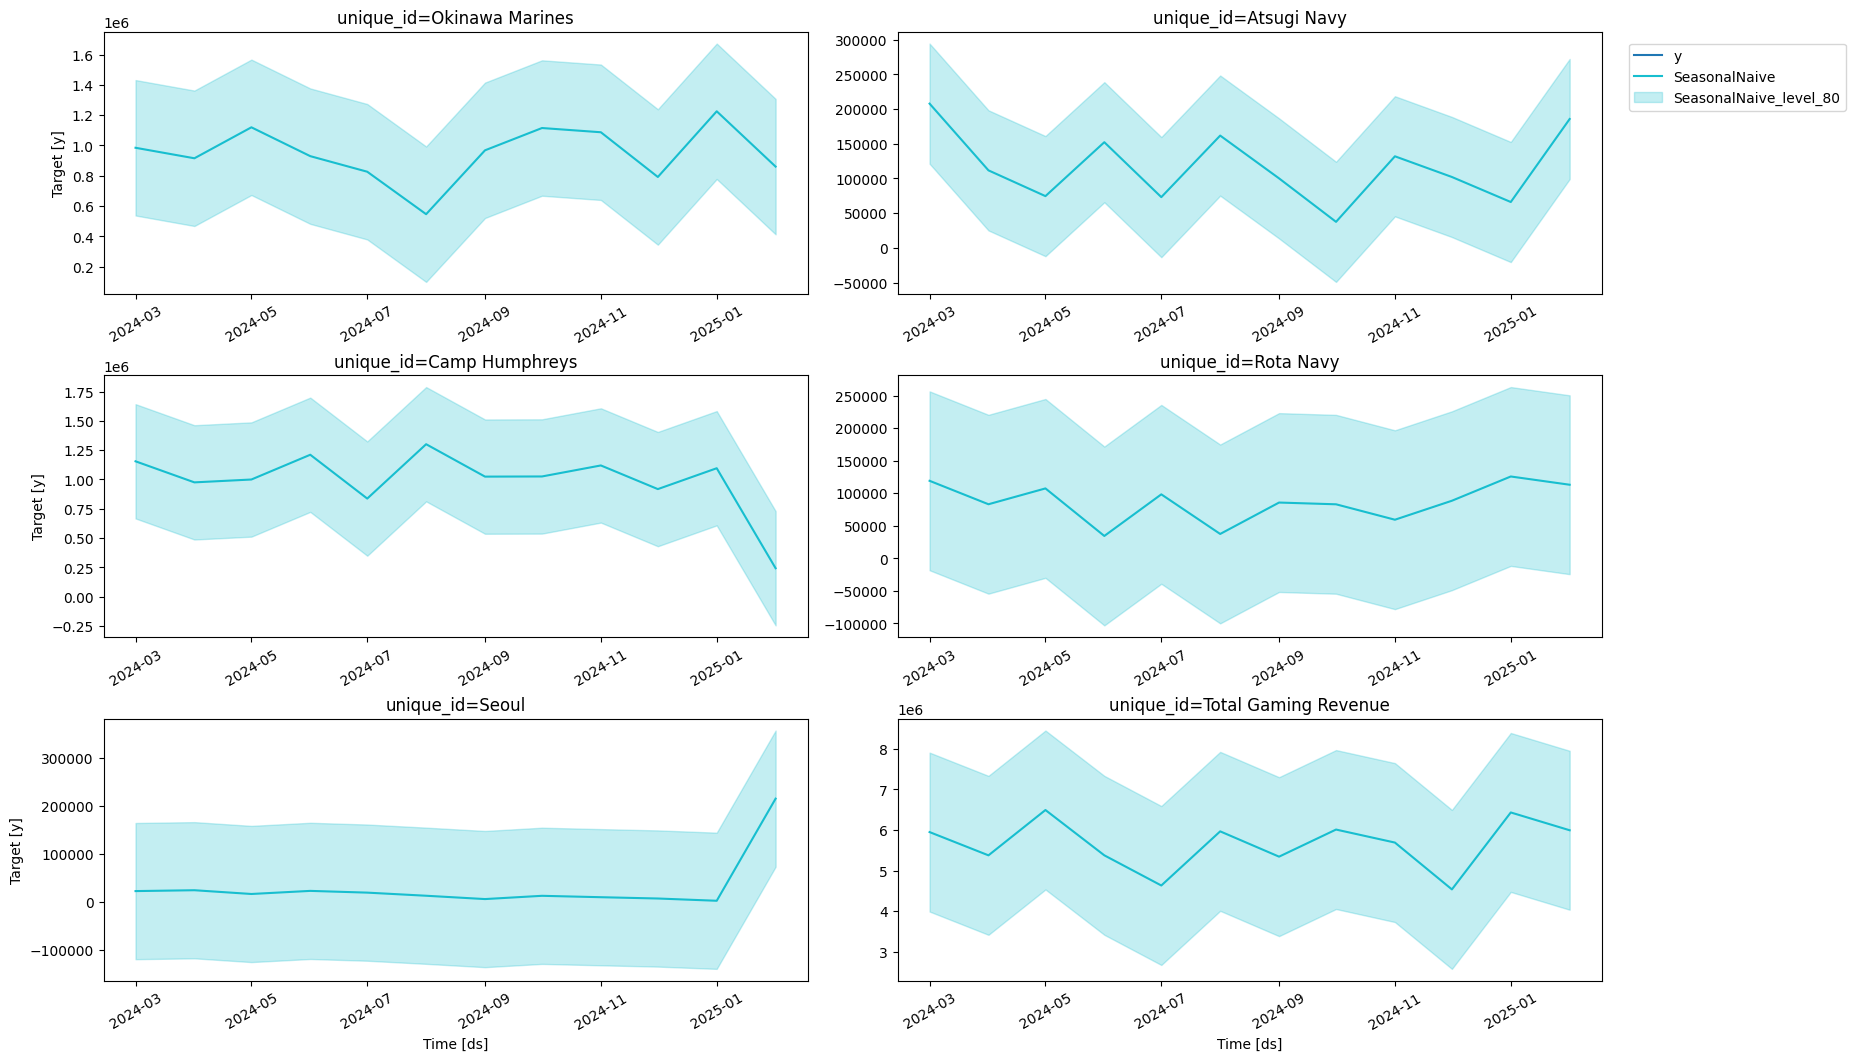

In [27]:
plot_series(
    df=test_df, 
    forecasts_df=prob_preds, 
    ids=['Okinawa Marines', 'Atsugi Navy',
        'Camp Humphreys', 'Rota Navy', 'Seoul',
        'Total Gaming Revenue'
        ], 
    max_insample_length=140, 
    level=[80]
    )


In [28]:
# Interactive prediction cell
print("Please enter the month you want to predict (format: 'YYYY-MM'):")
target_month_input = input("Month to predict (e.g., 2024-06): ")

try:
    # Convert input to datetime
    target_date = pd.to_datetime(target_month_input)
    
    # Check if the month is within our prediction horizon
    preds_month = preds[preds['ds'] == target_date]
    
    if not preds_month.empty:
        print(f"\nPredictions for {target_month_input}:")
        print("=" * 50)
        
        # Get predictions for all unique_ids (locations)
        for idx, row in preds_month.iterrows():
            print(f"\nLocation: {row['unique_id']}")
            print(f"  Prediction: ${row['SeasonalNaive']:,.2f}")
        
        # Special section for "Total Gaming Revenue"
        total_revenue_pred = preds_month[preds_month['unique_id'] == 'Total Gaming Revenue']
        if not total_revenue_pred.empty:
            print("\n" + "=" * 50)
            print("SPECIAL: Total Gaming Revenue Prediction")
            print("=" * 50)
            for idx, row in total_revenue_pred.iterrows():
                print(f"  Prediction: ${row['SeasonalNaive']:,.2f}")
    else:
        print(f"\nWarning: No prediction available for {target_month_input}")
        print(f"Available prediction months are:")
        available_months = preds['ds'].dt.strftime('%Y-%m').unique()
        for month in available_months:
            print(f"  - {month}")
        print("This model predicts only 1 year in future than the data provided for authenticity")
except ValueError:
    print("Invalid date format. Please use format 'YYYY-MM' (e.g., 2024-06)")
except Exception as e:
    print(f"An error occurred: {e}")

Please enter the month you want to predict (format: 'YYYY-MM'):

Predictions for 2024-04:

Location: AFRC Dragon Hill Lodge
  Prediction: $459,685.70

Location: AFRC Edelweiss Lodge
  Prediction: $40,045.42

Location: Ansbach
  Prediction: $61,184.60

Location: Atsugi Navy
  Prediction: $111,709.05

Location: Baumholder
  Prediction: $51,980.25

Location: Brunssum
  Prediction: $10,876.95

Location: Camp Humphreys
  Prediction: $975,030.85

Location: Camp Mujuk Marines
  Prediction: $0.00

Location: Camp Zama
  Prediction: $123,613.75

Location: Casey & Hovey
  Prediction: $131,300.15

Location: Chinhae Navy
  Prediction: $26,021.95

Location: Daegu
  Prediction: $206,373.05

Location: Fuji Marines
  Prediction: $3,844.00

Location: Grafenwoehr
  Prediction: $124,905.10

Location: Hohenfels
  Prediction: $26,466.95

Location: Iwakuni Marines
  Prediction: $129,822.35

Location: Kaiserslautern
  Prediction: $316,788.65

Location: Livorno
  Prediction: $0.00

Location: Naples Navy
  Pred